In [1]:
"""
What is an image?
to a computer, an image is just a grid of numbers, specially a multi-dimensional matrix.
Grayscale Images: 2D matrix, each element represents the intensity of light at that pixel (0-255).
Color Images: 3D matrix, with dimensions (height, width, channels). Each pixel
has three values (R, G, B) representing the intensity of red, green, and blue.

why 0-255?
This range is used because it can be represented in 8 bits (1 byte) per channel, which is a common standard for image storage and processing. Each channel (R, G, B) can have 256 possible values (0-255), allowing for a wide range of colors and shades in images.

"""

'\nWhat is an image?\nto a computer, an image is just a grid of numbers, specially a multi-dimensional matrix.\nGrayscale Images: 2D matrix, each element represents the intensity of light at that pixel (0-255).\nColor Images: 3D matrix, with dimensions (height, width, channels). Each pixel\nhas three values (R, G, B) representing the intensity of red, green, and blue.\n\nwhy 0-255?\nThis range is used because it can be represented in 8 bits (1 byte) per channel, which is a common standard for image storage and processing. Each channel (R, G, B) can have 256 possible values (0-255), allowing for a wide range of colors and shades in images.\n\n'

In [2]:
"""
Numpy arrays: the engine of CV

numpy is a powerful library for numerical computing in Python, and it provides support for multi-dimensional arrays, which are essential for image processing tasks. In computer vision, images are often represented as numpy arrays, allowing for efficient manipulation and analysis of pixel data.
numpy arrays are written in C, which makes them much faster than regular Python lists for numerical operations. This efficiency is crucial when working with large images or performing complex transformations, as it allows for faster processing and real-time applications in computer vision.

"""

'\nNumpy arrays: the engine of CV\n\nnumpy is a powerful library for numerical computing in Python, and it provides support for multi-dimensional arrays, which are essential for image processing tasks. In computer vision, images are often represented as numpy arrays, allowing for efficient manipulation and analysis of pixel data.\nnumpy arrays are written in C, which makes them much faster than regular Python lists for numerical operations. This efficiency is crucial when working with large images or performing complex transformations, as it allows for faster processing and real-time applications in computer vision.\n\n'

In [10]:
# Example numpy

import numpy as np

my_list = [1, 2, 3]
my_array = np.array(my_list) # Convert list to numpy array

# Create specific shapes (useful for creating blank images/masks)
zeros = np.zeros((512, 512)) # Create a 512x512 array filled with zeros (black image)
ones = np.ones((100, 100)) # Create a 100x100 array filled with ones (white image)

random_noise = np.random.randint(0, 256, (100, 100, 3)) # Create a 100x100 color image with random pixel values (0-255)

print(random_noise.shape) # Output: (100, 100, 3)
print(random_noise.dtype) # Output: uint8 (unsigned 8-bit integer, common for image data)

# slicing and indexing
# syntax: array[row_start:row_end, col_start:col_end]
# example: extract a 50x50 region from the top-left corner of the random_noise
region_of_interest = random_noise[0:50, 0:50] # Extract the top-left 50x50 region
print(region_of_interest.shape) # Output: (50, 50, 3)
print(ones)

(100, 100, 3)
int64
(50, 50, 3)
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


(1280, 1920, 3)


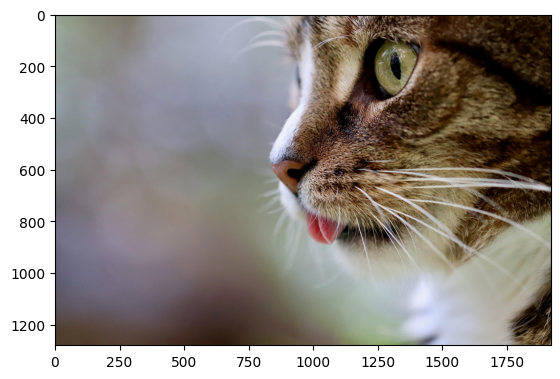

In [7]:
# Images and numpy (PIL & matplotlib)
# In standard Python, we use the Python Imaging Library (PIL) to open files, and Matplotlib to show them on the screen. Here is how you bridge the gap between an image file and a NumPy matrix.

import matplotlib.pyplot as plt
from PIL import Image

pic = Image.open("./data/images/nennieinszweidrei-cat-5628953_1920.jpg")

# convert to numpy array
pic_array = np.array(pic)
print(pic_array.shape) # Output: (height, width, channels)

plt.imshow(pic_array) # Display the image using Matplotlib
plt.show() # Show the plot

In [9]:
arrays_of_ten = np.full((5, 5), 10)
arrays_of_ten

array([[10, 10, 10, 10, 10],
       [10, 10, 10, 10, 10],
       [10, 10, 10, 10, 10],
       [10, 10, 10, 10, 10],
       [10, 10, 10, 10, 10]])

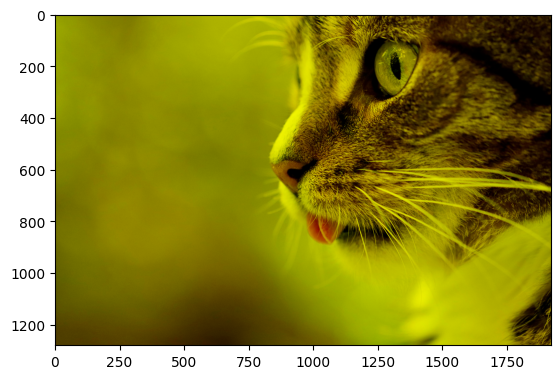

In [11]:
pic_copy = pic_array.copy() # Create a copy of the original image array
# An image array shape is (height, width, channels)
# in matplotlib, the channels are at index 0(red), 1(green), 2(blue))

pic_copy[:, :, 2] =0 # Set the blue channel to 0 (remove blue from the image)
plt.imshow(pic_copy) # Display the modified image
plt.show() # Show the plot

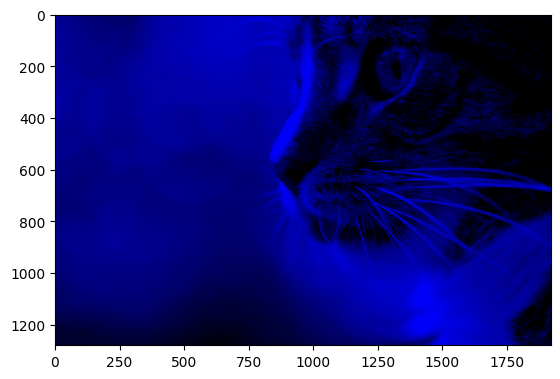

In [13]:
pic_copy = pic_array.copy() # Create a copy of the original image array
pic_copy[:, :, 0] =0
pic_copy[:, :, 1] =0
plt.imshow(pic_copy) # Display the modified image
plt.show() # Show the plot

In [1]:
"""
When you use Matplotlib and PIL, the channels are read as RGB (Red, Green, Blue).
Later, when we start using OpenCV (which you need for your embedded Raspberry Pi/Jetson deployment), it reads images in as BGR (Blue, Green, Red) due to historical hardware quirks.
If an interviewer asks why your colors look inverted (smurfs with red faces) when switching from OpenCV to Matplotlib, the answer is "OpenCV reads as BGR, but Matplotlib expects RGB."
"""


'\nWhen you use Matplotlib and PIL, the channels are read as RGB (Red, Green, Blue).\nLater, when we start using OpenCV (which you need for your embedded Raspberry Pi/Jetson deployment), it reads images in as BGR (Blue, Green, Red) due to historical hardware quirks.\nIf an interviewer asks why your colors look inverted (smurfs with red faces) when switching from OpenCV to Matplotlib, the answer is "OpenCV reads as BGR, but Matplotlib expects RGB."\n'

In [2]:
"""
Why CV Engineers Always Convert to NumPy
In computer vision, we almost never just look at an image. We manipulate it.

PIL Images are Objects, Not Matrices: The pic variable is a specialized PIL.JpegImagePlugin.JpegImageFile object. It has methods like .save() or .rotate(), but it does not support raw mathematical matrix operations.

Deep Learning Requires Numbers: When you eventually pass this image into YOLOv8 or PyTorch, the neural network only understands tensors (which are essentially advanced NumPy arrays). You cannot feed a PIL object into a neural network.

Array Slicing: If you want to crop out a helmet, you need to use array indexing (like pic_arr[100:200, 300:400]). You cannot slice a PIL object that way.

So, while Matplotlib might let you get away with plt.imshow(pic), converting it to a NumPy array immediately is a mandatory habit for building CV pipelines.
"""

'\nWhy CV Engineers Always Convert to NumPy\nIn computer vision, we almost never just look at an image. We manipulate it.\n\nPIL Images are Objects, Not Matrices: The pic variable is a specialized PIL.JpegImagePlugin.JpegImageFile object. It has methods like .save() or .rotate(), but it does not support raw mathematical matrix operations.\n\nDeep Learning Requires Numbers: When you eventually pass this image into YOLOv8 or PyTorch, the neural network only understands tensors (which are essentially advanced NumPy arrays). You cannot feed a PIL object into a neural network.\n\nArray Slicing: If you want to crop out a helmet, you need to use array indexing (like pic_arr[100:200, 300:400]). You cannot slice a PIL object that way.\n\nSo, while Matplotlib might let you get away with plt.imshow(pic), converting it to a NumPy array immediately is a mandatory habit for building CV pipelines.\n'

In [ ]:
# syntax of np.random.randint:
# np.random.randint(low, high=None, size=None, dtype=int)
# low: The lowest (inclusive) integer to be drawn from the distribution.
# high: The highest (exclusive) integer to be drawn from the distribution. If None (the default), then results are from [0, low).
# size: The shape of the output array. If the size is None (default), a single integer is returned.
# dtype: The desired data type of the output array. The default is int. If dtype is not specified, it will be inferred from the other arguments. For example, if low and high are integers, the output



moving to opencv

In [4]:
import cv2
import matplotlib.pyplot as plt

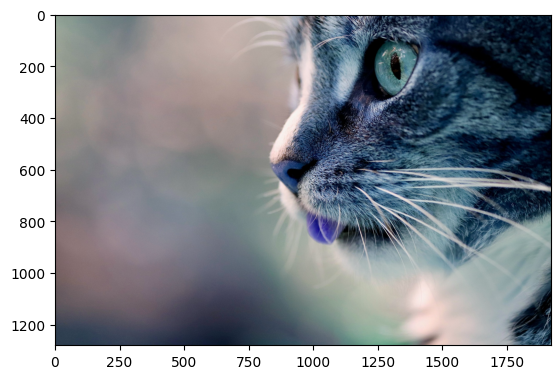

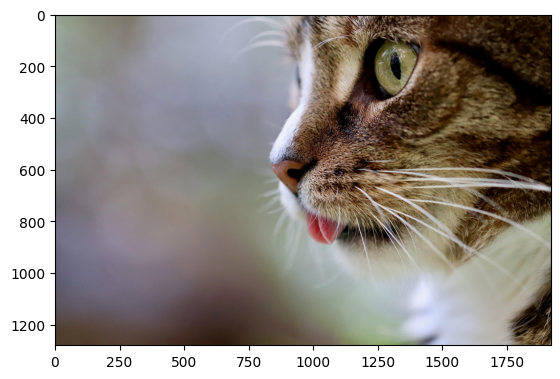

In [9]:
# this is how you read an image with OpenCV
img = cv2.imread("./data/images/nennieinszweidrei-cat-5628953_1920.jpg")
# print(img.shape) # Output: (height, width, channels)
plt.imshow(img) # Display the image using Matplotlib
plt.show()
# Convert BGR to RGB for displaying with Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # Display the image using Matplotlib
plt.show() # Show the plot

Interview tip:

if the script return white blank image it means the path to image is wrong and cv2.imread() is returning NONE

The UI trap:

Jupyter Notebooks are great for data science, but OpenCV's GUI functions (cv2.imshow) were built for standalone scripts (running from the terminal). If you run cv2.imshow in a Jupyter Notebook, the kernel will often freeze and crash.

When writing a Python script to display an image or video feed, you must use a specific loop. Here is the exact template you will use for your Raspberry Pi/Jetson deployment:

In [ ]:
img = cv2.imread("./data/images/young-male-construction-worker-wearing-hardhat-side-view.webp")
cv2.imshow("Construction Worker", img) # Display the image in a window
# WAITKEY: This is mandatory. 
# cv2.waitKey(0) means "pause the program forever until any key is pressed."
# cv2.waitKey(1) means "pause for 1 millisecond, then continue." (Used for video/webcams)
cv2.waitKey(0)

# Once a key is pressed, close the C++ window to free up memory
cv2.destroyAllWindows()

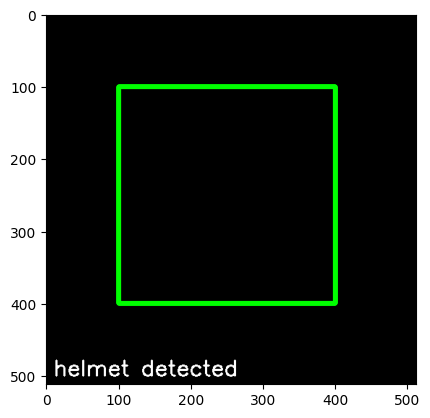

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# When you "draw" on an image in OpenCV, you aren't adding a layer on top. You are physically changing the numbers in the underlying NumPy matrix. This is destructive. Always draw on a copy if you need the original data later.

blank_img = np.zeros((512, 512, 3), dtype=np.uint8) # Create a blank black image
# 1. Draw a Rectangle (e.g., a YOLO bounding box)
# pt1: Top-left corner, pt2: Bottom-right corner
# color: (B, G, R) format -> (0, 255, 0) is pure Green
# thickness: integer
cv2.rectangle(blank_img, (100, 100), (400, 400), (0, 255, 0), thickness=5) # Draw a green rectangle on the blank image

# add text
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(blank_img, text = "helmet detected", org=(10, 500), fontFace = font, fontScale=1, color=(255, 255, 255), thickness=2) # Add white text to the image
plt.imshow(blank_img) # Display the image with the rectangle and text
plt.show() # Show the plot

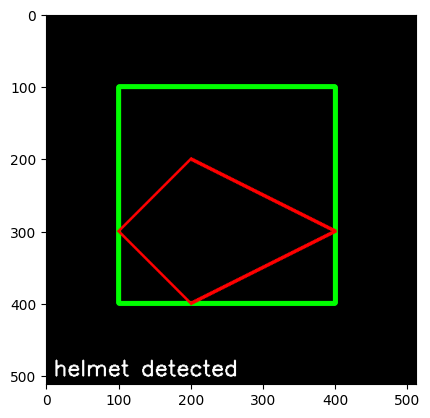

In [6]:
# Define vertices
vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)

# Reshape to 3D: -1 means "figure out this dimension automatically", 1 is a dummy dimension, 2 is for x,y
pts = vertices.reshape((-1, 1, 2))

# Draw the polygon (isClosed=True connects the last point to the first)
cv2.polylines(blank_img, [pts], isClosed=True, color=(255, 0, 0), thickness=3)
plt.imshow(blank_img) # Display the image with the polygon
plt.show() # Show the plot

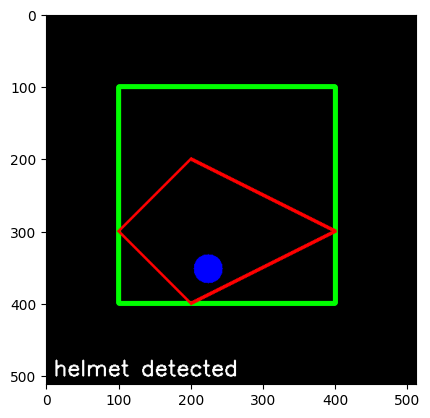

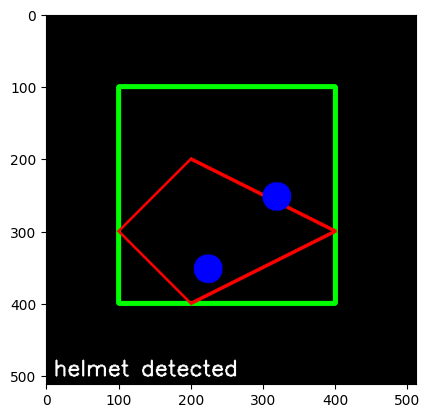

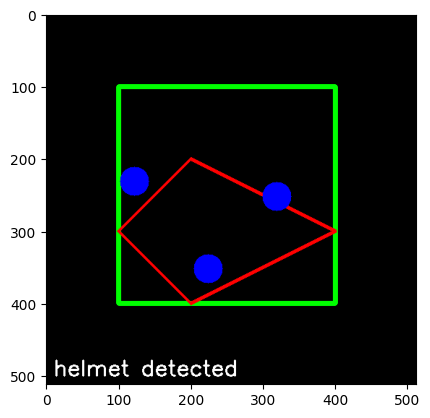

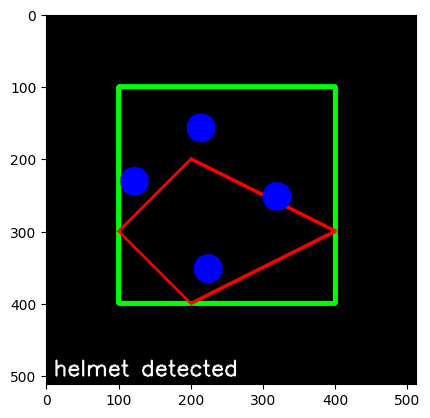

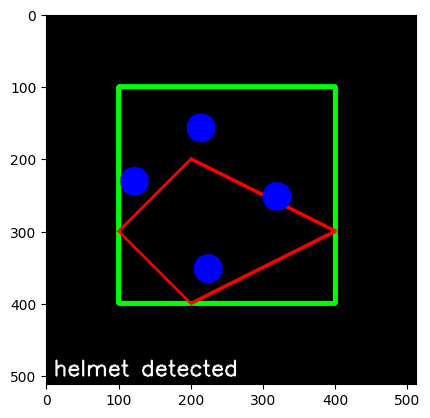

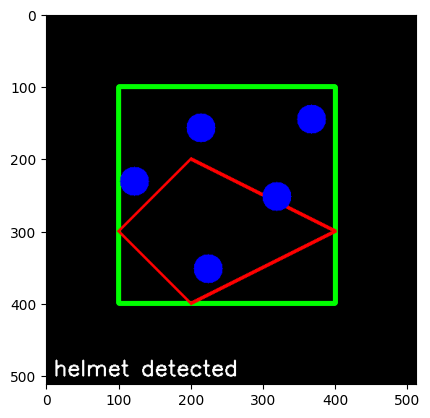

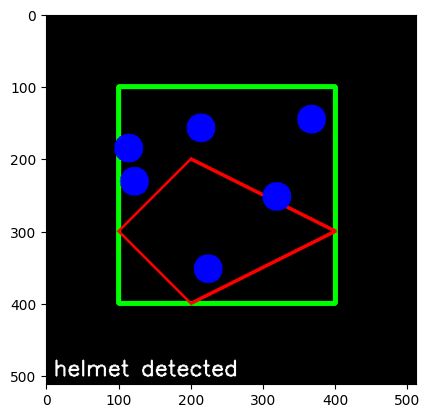

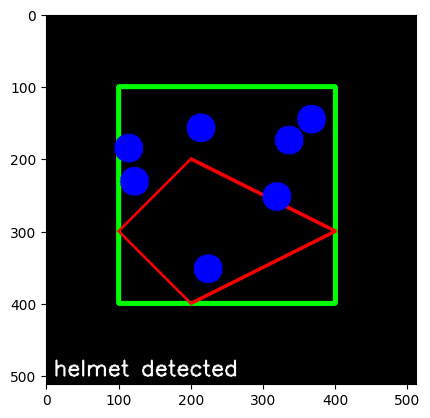

In [7]:
# to draw with a mouse, we use Event_Driven Programming (Event)
# Instead of code running top-to-bottom, we define a function (a "callback") that sits quietly in the background and only executes when a specific event (like a mouse click) happens.

def draw_circle(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN: # Check if the left mouse button was clicked
        cv2.circle(blank_img, (x, y), radius=20, color=(0, 0, 255), thickness=-1) # Draw a red circle at the click location
        plt.imshow(blank_img) # Display the updated image with the new circle
        plt.show() # Show the plot


cv2.namedWindow('image') # Create a window
# namedWindow reserves a specific window name in memory
cv2.setMouseCallback('image', draw_circle) # Set the mouse callback function
# setMouseCallback tells OpenCV: Hey, whenever a mouse event happens in the window named 'image', call the draw_circle function and pass it the event details (like the type of event and the x,y coordinates)."


img = np.zeros((512, 512, 3), dtype=np.uint8) # Create a blank black image
while True:
    cv2.imshow('image', img) # Display the image in the window
    if cv2.waitKey(1) & 0xFF == ord('q'): # Wait for the 'q' key to be pressed to exit
        break

cv2.destroyAllWindows() # Close the window

In [ ]:
# The drag-and_Drop Rectangle
# We need to track two points: the starting point (where the mouse button is pressed down
# and the ending point (where the mouse button is released). We also need to track whether the mouse button is currently being held down (dragging).

# --- 1. GLOBALS
drawing = False #True if mouse is pressed
ix, iy = -1, -1 # Initial x,y coordinates of the mouse

# --- 2. MOUSE CALLBACK FUNCTION
def draw_rectangle(event, x, y, flags, param):
    global ix, iy, drawing # Use the global variables defined above
    if event == cv2.EVENT_LBUTTONDOWN: # When the left mouse button is pressed down
        drawing = True # Start drawing
        ix, iy = x, y # Record the initial coordinates
    elif event == cv2.EVENT_MOUSEMOVE: # When the mouse is moved
        if drawing: # If we are currently drawing (mouse button is held down)
            pass
    elif event == cv2.EVENT_LBUTTONUP: # When the left mouse button is released
        drawing = False # Stop drawing
        cv2.rectangle(img, (ix, iy), (x, y), (0, 255, 0), thickness=2) # Draw the final rectangle on the original image

# --- 3. SETUP WINDOW AND CALLBACK
img = np.zeros((512, 512, 3), dtype=np.uint8) # Create a blank black image
cv2.namedWindow('image') # Create a window named 'image'
cv2.setMouseCallback('image', draw_rectangle) # Set the mouse callback function to our draw_rectangle function

# --- 4. MAIN LOOP
while True:
    cv2.imshow('image', img) # Display the image in the window
    if cv2.waitKey(1) & 0xFF == ord('q'): # Wait for the 'q' key to be pressed to exit
        break

cv2.destroyAllWindows() # Close the window
for i in range(5):
    cv2.waitKey(1)

: 

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

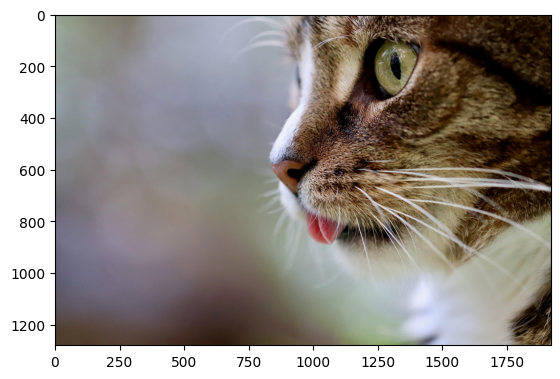

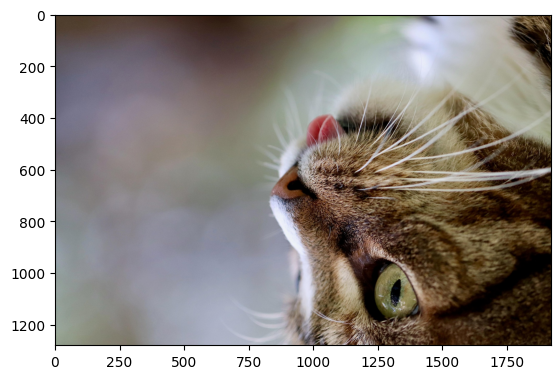

In [4]:
# flippinng an image
# 0 means flipping around the x-axis (vertical flip)
# 1 means flipping around the y-axis (horizontal flip)
# -1 means flipping around both axes (vertical and horizontal flip)

img = cv2.imread("./data/images/nennieinszweidrei-cat-5628953_1920.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb) # Display the original image
plt.show() # Show the plot
flipped_vertically = cv2.flip(img_rgb, 0) # Flip the image vertically
flipped_horizontally = cv2.flip(img_rgb, 1) # Flip the image horizontally
flipped_both = cv2.flip(img_rgb, -1) # Flip the image both

plt.imshow(flipped_vertically) # Display the vertically flipped image
plt.show()

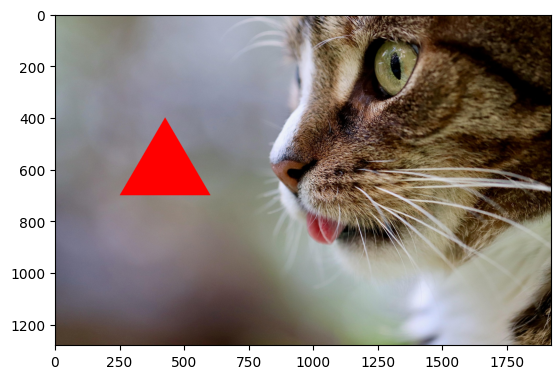

In [8]:
# We learned cv2.polylines for drawing the outline of a polygon. But what if the assessment asks you to draw a solid blue triangle over the dog
# 1. Define the 3 points of the triangle
# (Make sure to pass them as a list of lists)
vertices = np.array([[250, 700], [425, 400], [600, 700]], dtype=np.int32)

# 2. Reshape to the required 3D format for OpenCV (4, 1, 2)
pts = vertices.reshape((-1, 1, 2))

# 3. Draw the SOLID polygon
# Color is BGR if using cv2.imshow, or RGB if using plt.imshow!
cv2.fillPoly(img_rgb, [pts], color=(255, 0, 0)) # Pure Red (if RGB) or Pure Blue (if BGR)
plt.imshow(img_rgb) # Display the image with the polygon
plt.show() # Show the plot